# Varied Salinity Data Exploration and Interpolation #
Author: Maddox Chastain

Summer 2026

## 1.0 Introduction ##
This is where I will explore varied salintiy data and interpolate the values which may exist between data points using piecewise function concepts. 

### 1.1 Notes (will delete later) ###

- load in "Sample Bottom in Section [cm]", "Salinity [‰]", and "Contamination" (this is exactly as written in spreadsheet- yay no weird spaces!!!)
- group by "Y", "YY", or nothing in contamination column
- plot each group on one plot by depth, each represented by different colored points. <-- initial exploration!!

In [1]:
import pandas as pd
import numpy as np # for np.interp ---> linear interpolation with piecewise continuity
import matplotlib.pyplot as plt

## 2.0 Exploration ##

In [11]:
df = pd.read_csv("/mnt/c/Users/maddo/onedrive/Desktop/Work stuff/SURF 2026/MAD-FF-Corrections-from-Varied-Salinity/spreadsheets/501-all-water-data_Master_23_03.csv")
df = df.sort_values(by='Top Depth of Sample [m b.s.f.]')

### 2.1 Exploration by Hole ###

#### 2.1.1 Messy Exploration ####

In [12]:
M0111A_sal = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'A'), 'Salinity [‰]']
M0111A_dep = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'A'), 'Top Depth of Sample [m b.s.f.]']
M0111A_Y = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'A') & (df['Contamination']== 'Y'), 'Salinity [‰]']
M0111A_Ydep = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'A') & (df['Contamination']== 'Y'), 'Top Depth of Sample [m b.s.f.]']
M0111A_YY = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'A') & (df['Contamination']== 'YY'), 'Salinity [‰]']
M0111A_YYdep = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'A') & (df['Contamination']== 'YY'), 'Top Depth of Sample [m b.s.f.]']

M0111B_sal = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'B'), 'Salinity [‰]']
M0111B_dep = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'B'), 'Top Depth of Sample [m b.s.f.]']
M0111B_Y = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'B') & (df['Contamination']== 'Y'), 'Salinity [‰]']
M0111B_Ydep = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'B') & (df['Contamination']== 'Y'), 'Top Depth of Sample [m b.s.f.]']
M0111B_YY = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'B') & (df['Contamination']== 'YY'), 'Salinity [‰]']
M0111B_YYdep = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'B') & (df['Contamination']== 'YY'), 'Top Depth of Sample [m b.s.f.]']

M0111C_sal = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'C'), 'Salinity [‰]']
M0111C_dep = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'C'), 'Top Depth of Sample [m b.s.f.]']
M0111C_Y = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'C') & (df['Contamination']== 'Y'), 'Salinity [‰]']
M0111C_Ydep = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'C') & (df['Contamination']== 'Y'), 'Top Depth of Sample [m b.s.f.]']
M0111C_YY = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'C') & (df['Contamination']== 'YY'), 'Salinity [‰]']
M0111C_YYdep = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'C') & (df['Contamination']== 'YY'), 'Top Depth of Sample [m b.s.f.]']

M0112A_sal = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'A'), 'Salinity [‰]']
M0112A_dep = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'A'), 'Top Depth of Sample [m b.s.f.]']
M0112A_Y = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'A') & (df['Contamination']== 'Y'), 'Salinity [‰]']
M0112A_Ydep = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'A') & (df['Contamination']== 'Y'), 'Top Depth of Sample [m b.s.f.]']
M0112A_YY = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'A') & (df['Contamination']== 'YY'), 'Salinity [‰]']
M0112A_YYdep = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'A') & (df['Contamination']== 'YY'), 'Top Depth of Sample [m b.s.f.]']

M0112B_sal = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'B'), 'Salinity [‰]']
M0112B_dep = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'B'), 'Top Depth of Sample [m b.s.f.]']
M0112B_Y = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'B') & (df['Contamination']== 'Y'), 'Salinity [‰]']
M0112B_Ydep = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'B') & (df['Contamination']== 'Y'), 'Top Depth of Sample [m b.s.f.]']
M0112B_YY = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'B') & (df['Contamination']== 'YY'), 'Salinity [‰]']
M0112B_YYdep = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'B') & (df['Contamination']== 'YY'), 'Top Depth of Sample [m b.s.f.]']

M0113A_sal = df.loc[(df['Site'] == 'M0113') & (df['Hole'] == 'A'), 'Salinity [‰]']
M0113A_dep = df.loc[(df['Site'] == 'M0113') & (df['Hole'] == 'A'), 'Top Depth of Sample [m b.s.f.]']
M0113A_Y = df.loc[(df['Site'] == 'M0113') & (df['Hole'] == 'A') & (df['Contamination']== 'Y'), 'Salinity [‰]']
M0113A_Ydep = df.loc[(df['Site'] == 'M0113') & (df['Hole'] == 'A') & (df['Contamination']== 'Y'), 'Top Depth of Sample [m b.s.f.]']
M0113A_YY = df.loc[(df['Site'] == 'M0113') & (df['Hole'] == 'A') & (df['Contamination']== 'YY'), 'Salinity [‰]']
M0113A_YYdep = df.loc[(df['Site'] == 'M0113') & (df['Hole'] == 'A') & (df['Contamination']== 'YY'), 'Top Depth of Sample [m b.s.f.]']

Text(0.5, 0.96, 'Salinity by Depth - IODP EXP501')

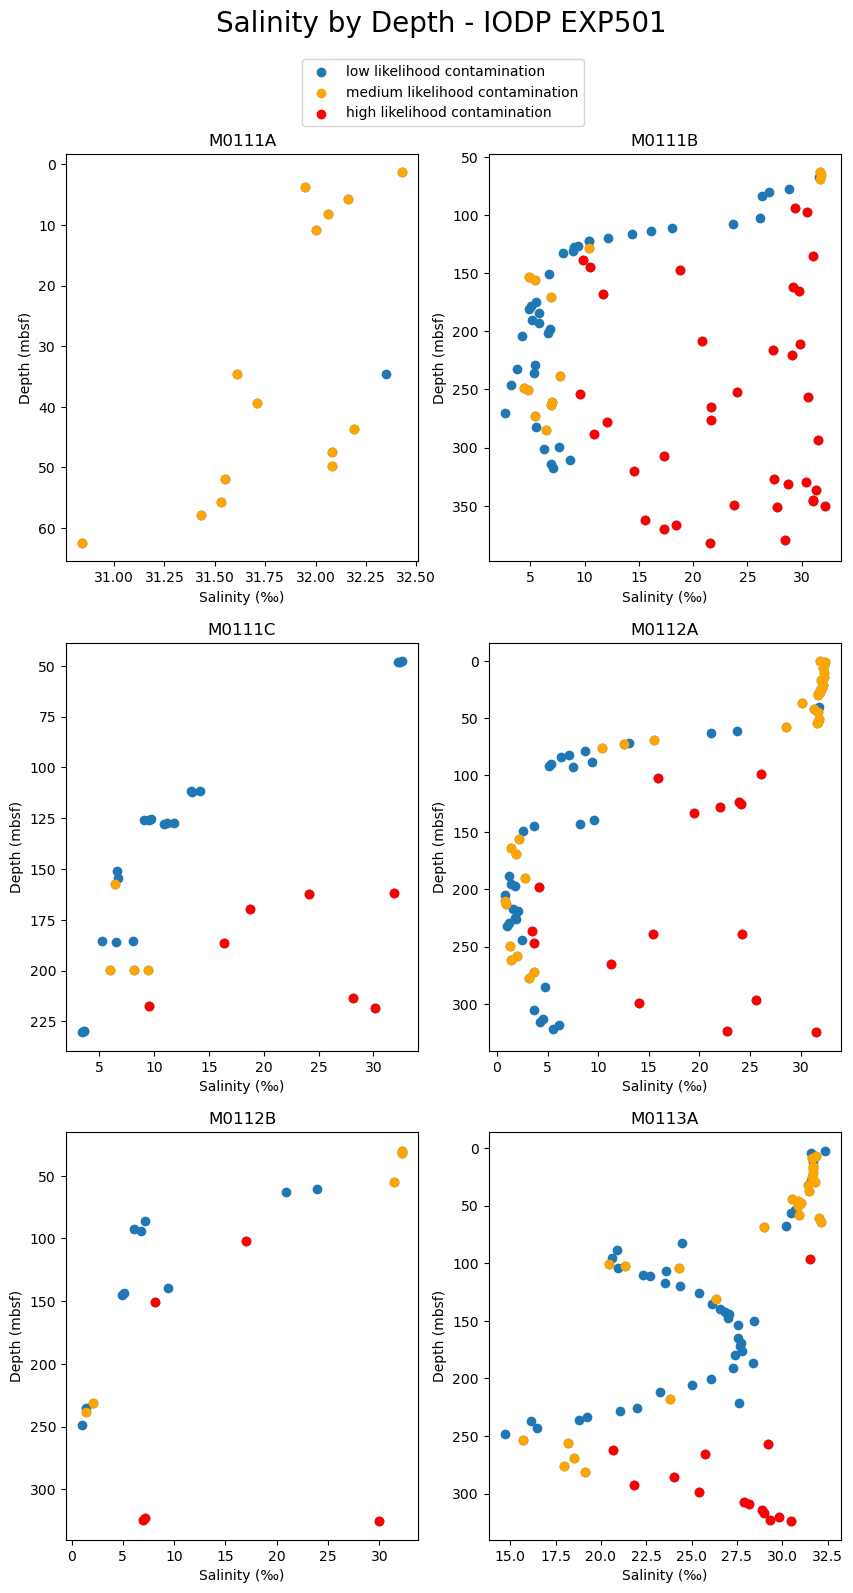

In [41]:
fig, ax = plt.subplots(3, 2, figsize=(10, 18))

X = ax[0,0].scatter(M0111A_sal, M0111A_dep)
Y = ax[0,0].scatter(M0111A_Y, M0111A_Ydep, color='orange')
YY = ax[0,0].scatter(M0111A_YY, M0111A_YYdep, color='red')
ax[0,0].yaxis.set_inverted(True)
ax[0,0].set_ylabel('Depth (mbsf)')
ax[0,0].set_xlabel('Salinity (‰)')
ax[0,0].set_title('M0111A')
ax[0,0].legend([X,Y,YY], ['low likelihood contamination', 'medium likelihood contamination', 'high likelihood contamination'], bbox_to_anchor=(0.65, 1.25), loc="upper left")

ax[0,1].scatter(M0111B_sal, M0111B_dep)
ax[0,1].scatter(M0111B_Y, M0111B_Ydep, color='orange')
ax[0,1].scatter(M0111B_YY, M0111B_YYdep, color='red')
ax[0,1].yaxis.set_inverted(True)
ax[0,1].set_ylabel('Depth (mbsf)')
ax[0,1].set_xlabel('Salinity (‰)')
ax[0,1].set_title('M0111B')

ax[1,0].scatter(M0111C_sal, M0111C_dep)
ax[1,0].scatter(M0111C_Y, M0111C_Ydep, color='orange')
ax[1,0].scatter(M0111C_YY, M0111C_YYdep, color='red')
ax[1,0].yaxis.set_inverted(True)
ax[1,0].set_ylabel('Depth (mbsf)')
ax[1,0].set_xlabel('Salinity (‰)')
ax[1,0].set_title('M0111C')

ax[1,1].scatter(M0112A_sal, M0112A_dep)
ax[1,1].scatter(M0112A_Y, M0112A_Ydep, color='orange')
ax[1,1].scatter(M0112A_YY, M0112A_YYdep, color='red')
ax[1,1].yaxis.set_inverted(True)
ax[1,1].set_ylabel('Depth (mbsf)')
ax[1,1].set_xlabel('Salinity (‰)')
ax[1,1].set_title('M0112A')

ax[2,0].scatter(M0112B_sal, M0112B_dep)
ax[2,0].scatter(M0112B_Y, M0112B_Ydep, color='orange')
ax[2,0].scatter(M0112B_YY, M0112B_YYdep, color='red')
ax[2,0].yaxis.set_inverted(True)
ax[2,0].set_ylabel('Depth (mbsf)')
ax[2,0].set_xlabel('Salinity (‰)')
ax[2,0].set_title('M0112B')

ax[2,1].scatter(M0113A_sal, M0113A_dep)
ax[2,1].scatter(M0113A_Y, M0113A_Ydep, color='orange')
ax[2,1].scatter(M0113A_YY, M0113A_YYdep, color='red')
ax[2,1].yaxis.set_inverted(True)
ax[2,1].set_ylabel('Depth (mbsf)')
ax[2,1].set_xlabel('Salinity (‰)')
ax[2,1].set_title('M0113A')

fig.suptitle('Salinity by Depth - IODP EXP501', fontsize=20, y=0.96)

#### 2.1.2 Clean Exploration ####

In [42]:
def clean_sal(site, hole):
    sal = df.loc[(df['Site'] == site) & (df['Hole'] == hole) & (df['Contamination'] != 'Y') & (df['Contamination'] != 'YY'), 'Salinity [‰]']
    return sal

def clean_dep(site, hole):
    dep = df.loc[(df['Site'] == site) & (df['Hole'] == hole) & (df['Contamination'] != 'Y') & (df['Contamination'] != 'YY'), 'Top Depth of Sample [m b.s.f.]']
    return dep

Text(0.5, 0.91, 'Salinity by Depth Without Contaminated Samples - IODP EXP501')

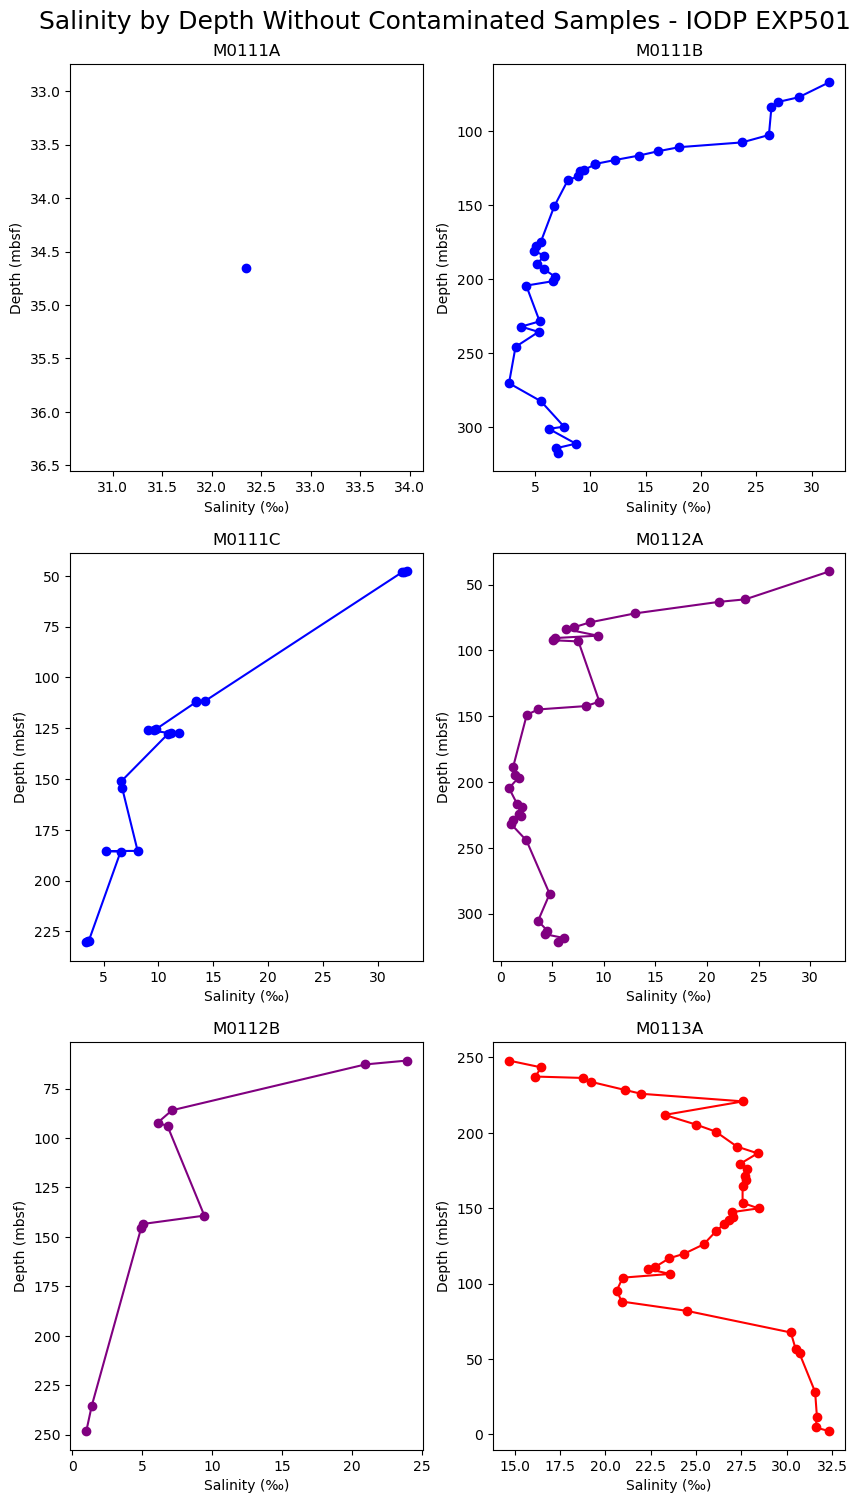

In [45]:
fig, ax = plt.subplots(3, 2, figsize=(10, 18))

ax[0,0].plot(clean_sal('M0111', 'A'), clean_dep('M0111', 'A'), marker='o', color='blue')
ax[0,0].yaxis.set_inverted(True)
ax[0,0].set_ylabel('Depth (mbsf)')
ax[0,0].set_xlabel('Salinity (‰)')
ax[0,0].set_title('M0111A')

ax[0,1].plot(clean_sal('M0111', 'B'), clean_dep('M0111', 'B'), marker='o', color='blue')
ax[0,1].yaxis.set_inverted(True)
ax[0,1].set_ylabel('Depth (mbsf)')
ax[0,1].set_xlabel('Salinity (‰)')
ax[0,1].set_title('M0111B')

ax[1,0].plot(clean_sal('M0111', 'C'), clean_dep('M0111', 'C'), marker='o', color='blue')
ax[1,0].yaxis.set_inverted(True)
ax[1,0].set_ylabel('Depth (mbsf)')
ax[1,0].set_xlabel('Salinity (‰)')
ax[1,0].set_title('M0111C')

ax[1,1].plot(clean_sal('M0112', 'A'), clean_dep('M0112', 'A'), marker='o', color='purple')
ax[1,1].yaxis.set_inverted(True)
ax[1,1].set_ylabel('Depth (mbsf)')
ax[1,1].set_xlabel('Salinity (‰)')
ax[1,1].set_title('M0112A')

ax[2,0].plot(clean_sal('M0112', 'B'), clean_dep('M0112', 'B'), marker='o', color='purple')
ax[2,0].yaxis.set_inverted(True)
ax[2,0].set_ylabel('Depth (mbsf)')
ax[2,0].set_xlabel('Salinity (‰)')
ax[2,0].set_title('M0112B')

ax[2,1].plot(clean_sal('M0113', 'A'), clean_dep('M0113', 'A'), marker='o', color='red')
ax[2,1].yaxis.set_inverted(True)
ax[2,1].set_ylabel('Depth (mbsf)')
ax[2,1].set_xlabel('Salinity (‰)')
ax[2,1].set_title('M0113A')

plt.gca().invert_yaxis()
fig.suptitle('Salinity by Depth Without Contaminated Samples - IODP EXP501', fontsize=18, y=0.91)

### 2.2 Exploration by Site ###

In [46]:
# interpolate by site or by hole? 
# should I exclude Y and YY contamination values or just YY? What would that mean for holes like M0111A?